# Fine-tuning QLoRA — Professions de foi (Archelec)

**Modèle :** `meta-llama/Llama-3.2-1B-Instruct`  
**GPU cible :** Tesla T4 (fp16, pas de bf16)  
**Objectif :** apprendre au modèle à générer des professions de foi crédibles à partir d'un prompt structuré.

**Pipeline :**
1. Authentification HuggingFace
2. Chargement dataset + métadonnées
3. Construction des prompts
4. Nettoyage OCR
5. Formatage chat template
6. Chargement modèle (QLoRA 4-bit)
7. Entraînement
8. Inférence & comparaison

In [2]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Found existing installation: torchaudio 2.11.0
Uninstalling torchaudio-2.11.0:
  Successfully uninstalled torchaudio-2.11.0


In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.5 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.6 MB/s  0:00:00eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 70.4 MB/s  0:00:07:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 55.9 MB/s  0:00:05:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 79.6 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 93.0 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 79.6 MB/s  0:00:01:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 86.6 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 82.3 MB/s  0:00:02:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 69.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 92.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 98.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 93.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 59.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 71.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 97.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 80.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 98.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 78.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 74.8 MB/s  0:00:00
  Attempting uninstall: fsspec0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  9/3

In [1]:
import torch

print("Version de PyTorch :", torch.__version__)
print("Version de CUDA associée :", torch.version.cuda)
print("Le GPU est-il détecté ? :", torch.cuda.is_available())

is_a2 = False
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print("Nom du GPU :", gpu_name)
    # L'instance A2 utilise généralement des GPU NVIDIA A100 ou A10
    if "A100" in gpu_name or "A10" in gpu_name or "A2" in gpu_name:
        is_a2 = True

Version de PyTorch : 2.10.0+cu128
Version de CUDA associée : 12.8
Le GPU est-il détecté ? : True
Nom du GPU : Tesla T4


## 1. Authentification HuggingFace

In [14]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

# override=True force la lecture de la nouvelle valeur dans le fichier .env
load_dotenv(override=True)
login(token=os.getenv("HF_TOKEN"))

## 2. Chargement du dataset et des métadonnées

On charge les fichiers texte (professions de foi OCRisées) et le CSV de métadonnées,
puis on les joint par l'identifiant de fichier (`id`).

In [3]:
from pathlib import Path
from datasets import load_dataset
import pandas as pd

# --- Fichiers texte à charger ---
PATTERNS = [
    "data/1981/legislatives/*PF*.txt",
    "data/1988/legislatives/*PF*.txt",
    "data/1993/legislatives/*PF*.txt",
]

# On résout les chemins dans le même ordre que load_dataset
# Note : load_dataset trie les fichiers par glob, on fait pareil avec sorted()
files = []
for p in PATTERNS:
    files.extend(sorted(Path().glob(p)))

dataset = load_dataset("text", data_files=PATTERNS, split="train", sample_by="document")
print(f"Dataset chargé : {len(dataset)} documents, {len(files)} fichiers résolus")

# --- Métadonnées ---
metadata = pd.read_csv("data/archelect_search.csv")
# Colonnes utiles uniquement
COLS_META = ["id", "titulaire-prenom", "titulaire-nom", "titulaire-profession",
             "titulaire-soutien", "contexte-tour", "date", "departement-nom"]
metadata_dict = metadata[COLS_META].set_index("id").to_dict("index")

print(f"Métadonnées : {len(metadata)} entrées")

Resolving data files:   0%|          | 0/12498 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset chargé : 12498 documents, 12498 fichiers résolus
Métadonnées : 12498 entrées


In [4]:
def add_metadata(example, idx):
    """Ajoute l'id (dérivé du nom de fichier) et les métadonnées associées."""
    path = files[idx]
    doc_id = path.stem
    example["id"] = doc_id
    example["annee"] = path.parts[-3]

    # Récupération des métadonnées (avec valeur par défaut si absent)
    meta = metadata_dict.get(doc_id, {})
    example["prenom"]     = meta.get("titulaire-prenom", "non mentionné")
    example["nom"]        = meta.get("titulaire-nom", "non mentionné")
    example["profession"] = meta.get("titulaire-profession", "non mentionné")
    example["soutien"]    = meta.get("titulaire-soutien", "non mentionné")
    example["tour"]       = meta.get("contexte-tour", "non mentionné")
    example["date"]       = meta.get("date", "non mentionné")
    example["departement"]= meta.get("departement-nom", "non mentionné")
    return example

dataset = dataset.map(add_metadata, with_indices=True)
print(dataset)

Map:   0%|          | 0/12498 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'id', 'annee', 'prenom', 'nom', 'profession', 'soutien', 'tour', 'date', 'departement'],
    num_rows: 12498
})


## 4. Nettoyage OCR

Les textes sont issus d'OCR et contiennent des artefacts courants :
mots coupés par un tiret en fin de ligne, filigranes CEVIPOF, mentions légales, etc.

**Attention :** on ne colle PAS les tirets intra-ligne (ex. `Bourg-en-Bresse`)
car cela détruirait les noms composés. On traite uniquement les coupures
**de fin de ligne** (tiret suivi d'un saut de ligne).

In [ ]:
import re

# --- Expressions régulières optimisées ---

# 1. Recoller les mots coupés par un tiret (césure)
# Capture un début de mot, un tiret, un espace éventuel (ou saut de ligne), puis la fin du mot.
# On exclut les tirets légitimes entre deux mots entiers (ex: "Sous-Préfet") 
# en exigeant qu'il y ait des espaces, tabulations ou sauts de ligne après le tiret.
_RE_HYPHENATION = re.compile(r'([A-Za-zÀ-ÿ]+)-\s+([A-Za-zÀ-ÿ]+)')

# 2. Nettoyer les lettres capitales isolées en début de paragraphe (Ex: "V AINCRE" -> "VAINCRE")
_RE_ISOLATED_CAP = re.compile(r'\b([A-Z])\s+([A-Z]+\b)')

_RE_WATERMARK  = re.compile(r'Sciences Po / fonds CEVIPOF|[☐☒@¥]')
_RE_VU_CAND    = re.compile(r'vu\s*[,:\-]?\s*(le|la|les)\s+candidat[e]?[s]?\s*[:.]?', re.IGNORECASE)
_RE_DROP_LINE  = re.compile(
    r'^.*('
    r'imp\.?\s|imprimerie|imprimeurs|'
    r'r\.?c\.?\s|'
    r'\b\d{5}\b|'
    r'\b\d{1,2}([\s.\-]?\d{2}){3}\b'
    r').*$',
    re.IGNORECASE | re.MULTILINE
)
_RE_MULTILINE  = re.compile(r'\n{3,}')
_RE_MULTSPACE  = re.compile(r' {2,}')
_RE_ENUM       = re.compile(r'[:\n]\s*[•*>.o·]\s*', re.MULTILINE)

def clean_ocr(example):
    text = str(example["text"]) # Sécurité pour éviter les erreurs de type
    
    # 1. Recoller les mots coupés (licen- ciements -> licenciements)
    text = _RE_HYPHENATION.sub(r'\1\2', text)
    
    # 2. Rattacher les lettrines / capitales isolées (V AINCRE -> VAINCRE)
    text = _RE_ISOLATED_CAP.sub(r'\1\2', text)
    
    # 3. Le reste de vos règles existantes
    text = _RE_WATERMARK.sub("", text)          
    text = _RE_VU_CAND.sub("", text)            
    text = _RE_DROP_LINE.sub("", text)          
    text = _RE_MULTILINE.sub('\n\n', text)      
    text = _RE_MULTSPACE.sub(' ', text)         
    text = _RE_ENUM.sub("- ", text)             
    
    example["text"] = text.strip()
    return example

dataset = dataset.map(clean_ocr, num_proc=4)
print("Nettoyage OCR terminé.")

Map (num_proc=4):   0%|          | 0/12498 [00:00<?, ? examples/s]

Nettoyage OCR terminé.


In [6]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

def normalize_party(soutien):
    # Exclusion directe des valeurs nulles ou non mentionnées
    if pd.isna(soutien) or soutien == "non mentionné":
        return "A_EXCLURE"

    # On isole le parti principal (le premier avant un éventuel point-virgule)
    # et on harmonise en minuscules pour la recherche
    s = str(soutien).lower().split(';')[0].strip()

    # 1. Extrême Droite
    if any(x in s for x in ["front national", "fn", "extrême droite", "trop d'immigrés", "nationaliste", "royaliste", "action française", "forces nouvelles"]):
        return "Extreme_Droite"

    # 2. Communiste et Extrême Gauche
    if any(x in s for x in ["communiste", "pcf", "lutte ouvrière", "lcr", "marxiste", "trotskyste", "parti des travailleurs", "rouge et vert", "psu", "parti socialiste unifié", "combat ouvrier", "alternative démocratie socialisme"]):
        return "Communiste_et_Extreme_Gauche"

    # 3. Écologiste (On exclut spécifiquement CPNT de cette catégorie)
    if any(x in s for x in ["écolog", "ecolog", "vert", "environnement", "amis de la terre", "nature et animaux", "biosphère"]) and "chasse" not in s:
        return "Ecologiste"

    # 4. Socialiste et Gauche modérée
    if any(x in s for x in ["socialiste", "ps", "mrg", "radicaux de gauche", "majorité présidentielle", "gauche progressiste", "convention des institutions républicaines"]):
        return "Socialiste"

    # 5. Droite (RPR, Gaullistes, Indépendants, PR)
    if any(x in s for x in ["rpr", "rassemblement pour la république", "gaulliste", "cni", "indépendants et paysans", "parti républicain", "droite", "républicain indépendant", "mouvement pour la france"]):
        return "Droite"

    # 6. Centre (UDF, CDS, Radicaux valoisiens)
    if any(x in s for x in ["udf", "union pour la démocratie française", "centre", "cds", "centriste", "démocratie chrétienne", "parti radical", "radicaux-socialistes", "réformateurs"]):
        return "Centre"

    # 7. Chasse / Ruralité (Typiquement classé à droite dans les comportements électoraux)
    if any(x in s for x in ["chasse", "cpnt", "rurale"]):
        return "Droite"

    # 8. Régionalistes / Indépendantistes (Très présents dans votre liste : Corse, DOM-TOM, Bretagne...)
    if any(x in s for x in ["corse", "corsica", "kanak", "polynési", "breton", "emgann", "occitan", "catalan", "savoie", "abertzale", "guadeloup", "martiniqu", "indépendantiste", "taatiraa", "tahoeraa"]):
        return "Regionaliste"

    # 9. Sans étiquette / Indépendants purs
    if any(x in s for x in ["sans étiquette", "apolitique", "hors des partis", "indépendant", "libre", "aucun parti", "sans appartenance"]):
        return "Sans_Etiquette"

    # 10. Tout le reste (micro-partis très spécifiques non classifiables)
    return "A_EXCLURE"

# Conversion en Pandas
df = dataset.to_pandas()

# 1. Application de la normalisation
df['famille_politique'] = df['soutien'].apply(normalize_party)

# 2. Purge des données inutiles ou indéterminées
df = df[df['famille_politique'] != "A_EXCLURE"]

# 3. Homogénéisation des tailles (entre 500 et 5000 caractères)
#df = df[(df['text'].str.len() >= 500) & (df['text'].str.len() <= 5000)]

# Optionnel : Vous pouvez vérifier la répartition avant d'échantillonner
print("Répartition des forces politiques dans le corpus nettoyé :")
print(df['famille_politique'].value_counts())

# 4. Échantillonnage stratifié (3000 documents)
# Assurez-vous que les classes très minoritaires ne fassent pas planter le split
# Si une catégorie a moins de 2 représentants, la stratification renverra une erreur.
# Le filtre suivant s'assure de ne garder que les catégories ayant au moins 10 représentants.
categories_valides = df['famille_politique'].value_counts()[df['famille_politique'].value_counts() >= 10].index
df = df[df['famille_politique'].isin(categories_valides)]

# df_train, _ = train_test_split(
#     df, 
#     train_size=3000, 
#     stratify=df['famille_politique'], 
#     random_state=42
# )

dataset = Dataset.from_pandas(df)
print(f"Dataset réduit et stratifié : {len(dataset)} documents.")

Répartition des forces politiques dans le corpus nettoyé :
famille_politique
Communiste_et_Extreme_Gauche    2365
Socialiste                      1397
Droite                          1367
Extreme_Droite                  1262
Ecologiste                      1197
Centre                           945
Sans_Etiquette                   290
Regionaliste                      46
Name: count, dtype: int64
Dataset réduit et stratifié : 8869 documents.


In [17]:
!pip install --upgrade --force-reinstall --no-cache-dir --no-deps unsloth unsloth_zoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 113.8 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: unsloth_zoo
    Found existing installation: unsloth_zoo 2026.4.6
    Uninstalling unsloth_zoo-2026.4.6:
      Successfully uninstalled unsloth_zoo-2026.4.6
  Attempting uninstall: unsloth━━━━━━━━━━━━━━━━━ 0/2 [unsloth_zoo]
    Found existing installation: unsloth 2026.4.40/2 [unsloth_zoo]
    Uninstalling unsloth-2026.4.4:90m╺━━━━━━━━━━━━━━━━━━━ 1/2 [unsloth]
      Successfully uninstalled unsloth-2026.4.4━━━━━━━━━━━━━━━ 1/2 [unsloth]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [unsloth]m1/2 [unsloth]


Map:   0%|          | 0/8869 [00:00<?, ? examples/s]

Le 95ème percentile de longueur est de 2348 tokens.


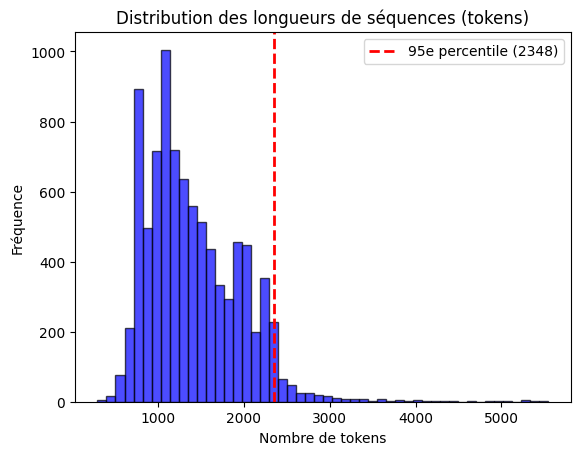

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import unsloth
from transformers import AutoTokenizer

# Assurez-vous d'utiliser le bon modèle si vous êtes passé au 8B
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct" 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def format_prompt_optimized(row):
    prompt_messages = [
        {
            "role": "system",
            "content": (
                "Tu es un expert en rhétorique politique française et un archiviste spécialisé "
                "dans l'histoire de la Ve République. Ta tâche est de rédiger une profession de "
                "foi électorale historique et convaincante. Tu dois adopter le ton, le vocabulaire "
                "et le positionnement idéologique correspondant au parti politique du candidat, "
                "en respectant scrupuleusement le contexte historique de l'année de l'élection. "
                "Le texte généré doit être structuré, persuasif, et s'adresser directement aux "
                "électeurs du département ciblé. Ne rédige que le corps du texte."
            )
        },
        {
            "role": "user",
            "content": (
                "Rédige la profession de foi à partir des caractéristiques suivantes :\n"
                f"- Candidat : {row['prenom']} {row['nom']}\n"
                f"- Profession : {row['profession']}\n"
                f"- Soutien politique : {row['soutien']}\n"
                f"- Élection : Élections législatives, Tour {row['tour']}\n"
                f"- Date : {row['date']}\n"
                f"- Département : {row['departement']}"
            )
        }
    ]
    
    # 1. Génération du prompt avec le template (jusqu'à la balise de l'assistant)
    row["prompt"] = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
    
    # 2. La "completion" est le texte de l'archive suivi du token de fin
    row["completion"] = row['text'] + tokenizer.eos_token
    
    return row

dataset = dataset.map(format_prompt_optimized)

# Analyse des longueurs sur la totalité du texte (prompt + completion)
lengths = [len(tokenizer.tokenize(row['prompt'] + row['completion'])) for row in dataset]
p95 = int(np.percentile(lengths, 95))
print(f"Le 95ème percentile de longueur est de {p95} tokens.")

global_max_seq_length = 2048 if p95 > 1024 else 1024

plt.hist(lengths, bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(p95, color='red', linestyle='dashed', linewidth=2, label=f'95e percentile ({p95})')
plt.title("Distribution des longueurs de séquences (tokens)")
plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

In [11]:
# Split train / test (90% / 10%)
splits = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = splits["train"]
test_dataset  = splits["test"]

print(f"Train : {len(train_dataset)} | Test : {len(test_dataset)}")

Train : 7982 | Test : 887


## 6. Chargement du modèle (QLoRA 4-bit)

**Points critiques pour la Tesla T4 :**
- La T4 **ne supporte pas `bf16`** (bfloat16). Il faut utiliser `fp16` (float16).
- On spécifie `torch_dtype=torch.float16` dès le chargement pour que Llama-3.2 
  charge directement ses couches non-quantifiées (lm_head, embed_tokens) en float16.
- Pas besoin de boucle de cast manuel après coup.

## 7. Entraînement

**Paramètres importants pour la T4 :**
- `fp16=True`, `bf16=False` — indispensable sur T4
- `optim="paged_adamw_32bit"` — optimiseur paginé du papier QLoRA, réduit la VRAM
- `max_seq_length=1024` — les professions de foi font souvent ~400-800 tokens,
  1024 est un bon compromis vitesse/couverture (2048 doublerait l'usage VRAM)
- `packing=True` — emballe plusieurs courtes séquences dans un même batch : accélère notablement l'entraînement

In [15]:
import os
import time
import glob
from trl import SFTTrainer, SFTConfig
from huggingface_hub import snapshot_download
from unsloth import FastLanguageModel
from transformers import EarlyStoppingCallback, TrainerCallback


# Initialisation du tableau de bord visuel externe (WandB)
version = time.strftime("%Y%m%d-%H%M")

OUTPUT_DIR = "./results_checkpoints"
REPO_ID = f"fdechamps/Llama-1B-Archelec-{version}" 

batch_size = 8 if is_a2 else 4
accum_steps = 2 if is_a2 else 4

# Chargement du modèle (load_in_4bit=True est activé pour QLoRA)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=global_max_seq_length,
    dtype=None,
    load_in_4bit=True, 
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0, 
    bias="none",
    use_gradient_checkpointing="unsloth", 
    random_state=42,
)

# Nettoyage strict : on indique au système de ne conserver QUE les deux nouvelles colonnes
colonnes_a_supprimer = [col for col in train_dataset.column_names if col not in ["prompt", "completion"]]
train_dataset_clean = train_dataset.remove_columns(colonnes_a_supprimer)
test_dataset_clean = test_dataset.remove_columns(colonnes_a_supprimer)

# class GenerationCallback(TrainerCallback):
#     def __init__(self, prompt_test):
#         self.prompt_test = prompt_test

#     def on_evaluate(self, args, state, control, model, tokenizer, **kwargs):
#         if state.global_step % 200 == 0:
#             print(f"\n--- ÉTAPE {state.global_step} : GÉNÉRATION TEST ---")
#             messages = [{"role": "user", "content": self.prompt_test}]
#             inputs = tokenizer.apply_chat_template(
#                 messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
#             ).to("cuda")
#             outputs = model.generate(
#                 input_ids=inputs, max_new_tokens=150, temperature=0.7, 
#                 do_sample=True, pad_token_id=tokenizer.eos_token_id
#             )
#             text = tokenizer.decode(outputs[0], skip_special_tokens=True)
#             reponse = text.split("assistant\n")[-1].strip() if "assistant\n" in text else text
#             print(reponse)
#             print("---------------------------------------------------\n")

# prompt_mid_training = (
#     "Rédige un court paragraphe de profession de foi pour Jean Dupont, candidat du Parti "
#     "Communiste Français en 1981, sur le thème du pouvoir d'achat."
# )

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size * 2,
    gradient_accumulation_steps=accum_steps,
    
    fp16=True,
    bf16=False,
    optim="adamw_8bit",
    weight_decay=0.01,
    
    # NOUVELLE MÉTHODE POUR LE MASQUAGE DU PROMPT
    completion_only_loss=True,
    
    max_length=global_max_seq_length,
    packing=False,
    
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,
    push_to_hub=True,
    hub_model_id=REPO_ID,
    hub_private_repo=True, 
    hub_strategy="checkpoint",
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset_clean,
    eval_dataset=test_dataset_clean,
    processing_class=tokenizer,
    args=training_args,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=5),
    ]
)

if not os.path.exists(OUTPUT_DIR) or len(os.listdir(OUTPUT_DIR)) == 0:
    try:
        snapshot_download(repo_id=REPO_ID, local_dir=OUTPUT_DIR)
    except Exception:
        pass

checkpoints = glob.glob(f"{OUTPUT_DIR}/checkpoint-*")
if len(checkpoints) > 0:
    trainer.train(resume_from_checkpoint=True)
else:
    trainer.train()

# Sauvegarde avec l'horodatage pour ne pas écraser le précédent travail
model.save_pretrained(f"Llama-1B-Archelec-Final-{version}")
tokenizer.save_pretrained(f"Llama-1B-Archelec-Final-{version}")
trainer.push_to_hub(commit_message="Entraînement terminé")

==((====))==  Unsloth 2026.4.4: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=64):   0%|          | 0/7982 [00:00<?, ? examples/s]

...

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.879912,1.800398
200,1.523529,1.629803
300,1.555717,1.560134
400,1.458871,1.518455
499,1.397469,1.511005


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/fdechamps/Llama-1B-Archelec-20260409-1742/commit/367420d7a508510daf35bf98815e91da5c4be9aa', commit_message='Entraînement terminé', commit_description='', oid='367420d7a508510daf35bf98815e91da5c4be9aa', pr_url=None, repo_url=RepoUrl('https://huggingface.co/fdechamps/Llama-1B-Archelec-20260409-1742', endpoint='https://huggingface.co', repo_type='model', repo_id='fdechamps/Llama-1B-Archelec-20260409-1742'), pr_revision=None, pr_num=None)

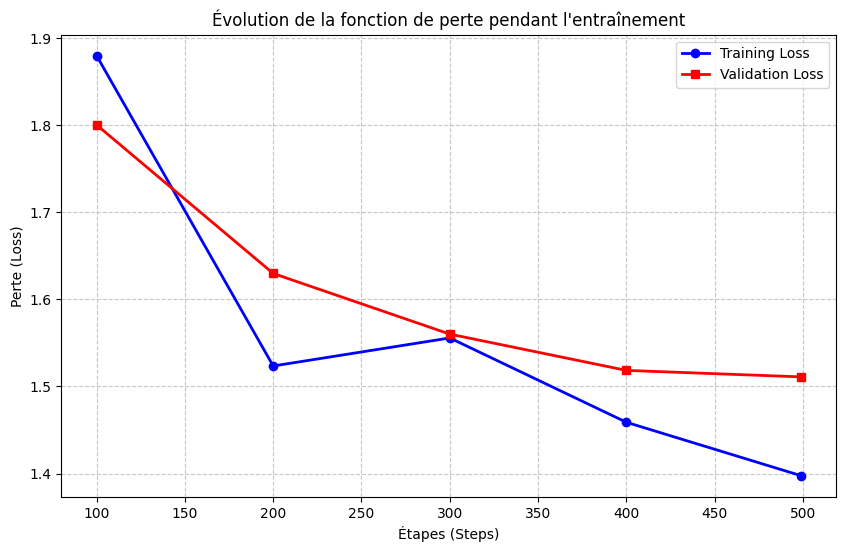

In [37]:
import matplotlib.pyplot as plt

# Données extraites de votre entraînement
steps = [100, 200, 300, 400, 499]
train_loss = [1.879912, 1.523529, 1.555717, 1.458871, 1.397469]
val_loss = [1.800398, 1.629803, 1.560134, 1.518455, 1.511005]

plt.figure(figsize=(10, 6))
plt.plot(steps, train_loss, label='Training Loss', marker='o', color='blue', linewidth=2)
plt.plot(steps, val_loss, label='Validation Loss', marker='s', color='red', linewidth=2)

plt.title('Évolution de la fonction de perte pendant l\'entraînement')
plt.xlabel('Étapes (Steps)')
plt.ylabel('Perte (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [22]:
from IPython.display import HTML

HTML("""
<style>
.output pre {
    white-space: pre-wrap;
    max-width: 800px;
}
</style>
""")

In [35]:
from transformers import TextStreamer

FastLanguageModel.for_inference(model)
text_streamer = TextStreamer(tokenizer, skip_prompt=True)

def test_model(prompt_text, max_token, use_lora=True):
    messages = [{"role": "user", "content": prompt_text}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    
    if use_lora:
        print("--- GÉNÉRATION (Modèle Fine-tuné) ---")
        model.generate(
            input_ids=inputs, streamer=text_streamer, max_new_tokens=max_token,
            temperature=0.6, top_p=0.9, repetition_penalty=1.2, do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    else:
        print("--- GÉNÉRATION (Modèle de Base Original) ---")
        with model.disable_adapter():
            model.generate(
                input_ids=inputs, streamer=text_streamer, max_new_tokens=max_token,
                temperature=0.7, top_p=0.9, repetition_penalty=1.2, do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
    print("\n" + "="*80 + "\n")


In [ ]:

# Liste des 8 profils sociologiquement représentatifs des années 80
candidats_test = [
    {
        "famille": "Extrême Droite",
        "prenom": "Martial", "nom": "Delaborde",
        "profession": "Artisan commerçant", 
        "soutien": "Front national",
        "departement": "Bouches-du-Rhône", "date": "1988", "tour": "1"
    },
    {
        "famille": "Droite",
        "prenom": "Charles-Henri", "nom": "de Courcelles",
        "profession": "Chef d'entreprise", 
        "soutien": "Rassemblement pour la République",
        "departement": "Hauts-de-Seine", "date": "1988", "tour": "1"
    },
    {
        "famille": "Centre",
        "prenom": "François", "nom": "Lemaire",
        "profession": "Médecin généraliste", 
        "soutien": "Union pour la démocratie française",
        "departement": "Calvados", "date": "1988", "tour": "1"
    },
    {
        "famille": "Socialiste",
        "prenom": "Alain", "nom": "Mignot",
        "profession": "Professeur de lycée", 
        "soutien": "Parti socialiste",
        "departement": "Nord", "date": "1988", "tour": "1"
    },
    {
        "famille": "Communiste",
        "prenom": "Marcel", "nom": "Roussillon",
        "profession": "Ouvrier métallurgiste", 
        "soutien": "Parti communiste français",
        "departement": "Seine-Saint-Denis", "date": "1988", "tour": "1"
    },
    {
        "famille": "Écologiste",
        "prenom": "Brigitte", "nom": "Valette",
        "profession": "Chercheuse en biologie", 
        "soutien": "Verts",
        "departement": "Isère", "date": "1988", "tour": "1"
    },
    {
        "famille": "Régionaliste",
        "prenom": "Yannick", "nom": "Le Goff",
        "profession": "Agriculteur", 
        "soutien": "Union démocratique bretonne",
        "departement": "Finistère", "date": "1988", "tour": "1"
    },
    {
        "famille": "Sans Étiquette",
        "prenom": "Bernard", "nom": "Dubois",
        "profession": "Boulanger retraité", 
        "soutien": "Sans étiquette",
        "departement": "Cantal", "date": "1988", "tour": "1"
    }
]

# Exécution de la boucle de test
print("DÉBUT DU TEST DE COMPARTIMENTATION IDÉOLOGIQUE\n")

for candidat in candidats_test:
    prompt = (
        "Rédige la profession de foi à partir des caractéristiques suivantes :\n"
        f"- Candidat : {candidat['prenom']} {candidat['nom']}\n"
        f"- Profession : {candidat['profession']}\n"
        f"- Soutien politique : {candidat['soutien']}\n"
        f"- Élection : Élections législatives, Tour {candidat['tour']}\n"
        f"- Date : {candidat['date']}\n"
        f"- Département : {candidat['departement']}"
    )
    
    titre_test = f"{candidat['famille'].upper()} - {candidat['soutien']}"
    print(f"{'='*80}\n>>> TEST : {titre_test}\n{'='*80}")
    
    # On utilise la fonction test_model définie précédemment, uniquement avec le modèle Fine-tuné
    test_model(prompt, max_token = 512, use_lora=True)
    
    # Petite pause optionnelle pour la lisibilité
    import time
    time.sleep(1)


In [31]:
test_dataset[0]

{'text': 'ELECTIONS LEGISLATIVES DU 21 MARS 1993 - 1ERE CIRCONSCRIPTION DE L\'YONNE\nJack Toupet informaticien\nRAIMENT\nsuppléant . Ambroise Vautour (technicien métallurgiste,\nD\'un côté, trois millions de chômeurs, deux millions de travailleurs précaires, cinq millions de mal-logés, les salaires bloqués, la Sécurité sociale menacée, la misère ...\nDe l\'autre côté, les scandales financiers, les profits en hausse, les fortunes fondées sur la spéculation.\nVOILÀ LE BILAN DE LA POLITIQUE MENÉE DEPUIS DOUZE ANS !\nCelle que Mitterrand a appliquée sans faillir. Le Parti socialiste a été l\'instrument de cette politique, il a trahi ses promesses et ses valeurs. Après son départ du gouvernement en 1984, le Parti com- muniste n\'a jamais proposé une autre politique.\nLa droite, on connaît. Elle va s\'appuyer sur ce qui a été fait pour aggraver encore la situation des salariés et accroître les avantages des privilégiés.\nLe Pen, c\'est vraiment le pire de tous. Il veut transformer le désespo

In [33]:
print(test_dataset['text'][0])

ELECTIONS LEGISLATIVES DU 21 MARS 1993 - 1ERE CIRCONSCRIPTION DE L'YONNE
Jack Toupet informaticien
RAIMENT
suppléant . Ambroise Vautour (technicien métallurgiste,
D'un côté, trois millions de chômeurs, deux millions de travailleurs précaires, cinq millions de mal-logés, les salaires bloqués, la Sécurité sociale menacée, la misère ...
De l'autre côté, les scandales financiers, les profits en hausse, les fortunes fondées sur la spéculation.
VOILÀ LE BILAN DE LA POLITIQUE MENÉE DEPUIS DOUZE ANS !
Celle que Mitterrand a appliquée sans faillir. Le Parti socialiste a été l'instrument de cette politique, il a trahi ses promesses et ses valeurs. Après son départ du gouvernement en 1984, le Parti com- muniste n'a jamais proposé une autre politique.
La droite, on connaît. Elle va s'appuyer sur ce qui a été fait pour aggraver encore la situation des salariés et accroître les avantages des privilégiés.
Le Pen, c'est vraiment le pire de tous. Il veut transformer le désespoir en haine raciste et imp

In [36]:
prompt = (
        "Rédige la profession de foi à partir des caractéristiques suivantes :\n"
        f"- Candidat : Jack Toupet\n"
        f"- Profession : Informaticien\n"
        f"- Soutien politique : Ligue communiste révolutionnaire\n"
        f"- Élection : Élections législatives, Tour 1\n"
        f"- Date : 1993-03-21\n"
        f"- Département : Yonne"
    )
test_model(prompt, max_token= 1000, use_lora=True)

Both `max_new_tokens` (=1000) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- GÉNÉRATION (Modèle Fine-tuné) ---
ELECTIONS 

/opt/python/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/opt/python/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


LEGISLATIVES DE MARS 93 - CIRCONSCRIPTION DE LA JOYE
Jack TOUPET
Député sortant Conseiller Régional d'Allier Secrétaire Fédéral du Comité Central du PCF (Maire de Châlus) Militant syndical et militant dans le mouvement associatif.
Suppléante : Marie-Claire BOURGARDÉ Maire adjoint de Montargis
Candidats présentés par La Ligue Communiste Révolutionnaire.
Chers compatriotes,
Le dimanche 21 mars prochain vous êtes appelés à voter pour élire votre député. Vous allez avoir besoin de lui au plan national puisque les élections ont été organisées en toute discrétion et sans vote ouvert aux communistes et à leurs militants.
Lorsqu'il est question de l'élection présidentielle il s'est passé avec quelques exceptions où se sont opposants à la droite et à son programme ont pu manifester leur volonté de contribuer au rassemblement des forces populaires qui ont gagné massivement lors du premier tour de scrutin.
Aujourd'hui comme hier nous sommes contre cette alliance entre la droite et une partie de l

In [34]:
prompt = (
        "Rédige la profession de foi à partir des caractéristiques suivantes :\n"
        f"- Candidat : Jack Toupet\n"
        f"- Profession : Informaticien\n"
        f"- Soutien politique : Ligue communiste révolutionnaire\n"
        f"- Élection : Élections législatives, Tour 1\n"
        f"- Date : 1993-03-21\n"
        f"- Département : Yonne"
    )
test_model(prompt, use_lora=True)

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- GÉNÉRATION (Modèle Fine-tuné) ---
ELECTIONS 

/opt/python/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/opt/python/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


LEGISLATIVES DE MARS 93 - 2ème CIRCONSCRIPTION DE LA JOYEAUX - CHATEAU-SALIN
Jack TOUPET
Informaticien Maire de Chateau-salins Conseiller Régional d'Allier
Candidats présentés par la Ligue Communiste Révolutionnaire.
Madame, Mademoiselle, Monsieur,
Le dimanche 14 mars prochain vous allez voter pour élire votre député. Vous allez choisir entre un candidat socialiste ou une candidate du Parti Communiste. Mais le vote que vous ferez est important car il décide de l'échec ou de la victoire du programme socialo-communiste qui a été largement approuvé dans notre circonscription depuis plusieurs années.
La droite n'est pas en position définitive mais elle s'appuiera sur les élections législatives afin de mettre en place une alliance avec le gouvernement pour imposer le retour au pouvoir des socialistes et casser toute chance de changement.
Vous avez pu voir ce qu'il implique ces deux partis dont les hommes sont responsables de tout malheur économique et moral, ni l'un ni l'autre ne peuvent ré

In [ ]:

# 2. Test des capacités intrinsèques
prompt_general = "Explique brièvement le principe de la séparation des pouvoirs."

print(">>> TEST DE CONTRÔLE : CAPACITÉS INTRINSÈQUES")
test_model(prompt_general, use_lora=False)
test_model(prompt_general, use_lora=True)